In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

1. Загрузите учебный набор данных для регрессии "gen_regression".

In [3]:
url = "https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML3.1%20polynomial%20features/data/gen_regression.csv"
data = pd.read_csv(url)
data.head()

,Unnamed: 0,x,y
0,0,96.597780,97761.592016
1,1,48.002892,27613.989207
2,2,47.939756,29410.187753
3,3,47.809026,15789.597531
4,4,69.784427,20953.383453


2. Постройте модель парной линейной регрессии, оцените ее эффективность, изобразите модель на графике.

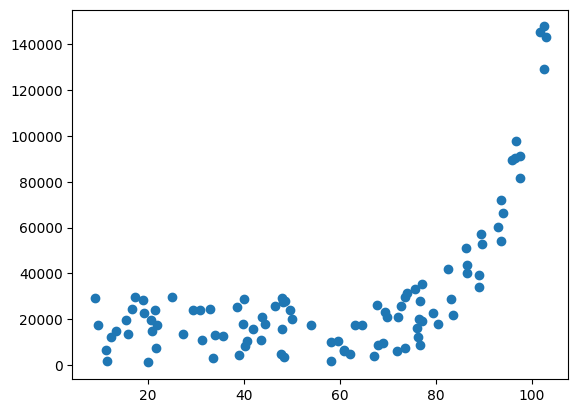

In [4]:
exersice = []
timer = []
scores = []
X = data.x
y = data.y
plt.scatter(X, y)

In [5]:
lr = LinearRegression()
X = pd.DataFrame(X)
start = time.time()
lr.fit(X, y)
end = time.time()
print(f'Time : {end - start}')

Time : 0.0010075569152832031


C:\Users\_System\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


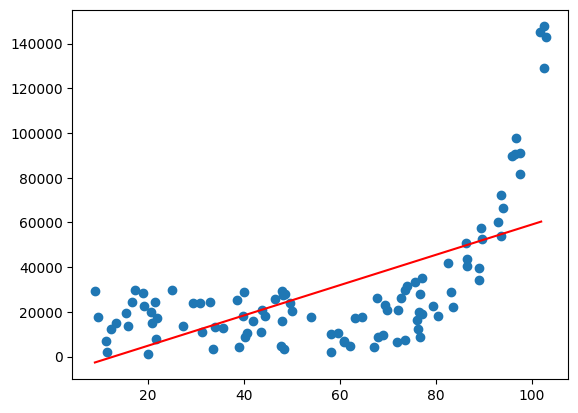

In [6]:
xx = np.arange(X.x.min(axis=0), X.x.max(axis=0))
yy = lr.predict(pd.DataFrame(xx))

plt.scatter(X.x, y)
plt.plot(xx, yy, c='r')
plt.show()

In [7]:
lr.score(X, y)

0.37467360318911636

In [8]:
exersice.append('reg')
timer.append(end - start)
scores.append(lr.score(X, y))

3. Постройте модель полиномиальной регрессии второго порядка. Сравните ее эффективность с первой моделью.

In [9]:
start = time.time()
transformation = PolynomialFeatures(degree=2)
end = time.time()
print("Time: ", end - start)

transformation.fit(X)

X_2 = transformation.transform(X)

X_2.shape
X_2[:5]

Time:  3.4809112548828125e-05


array([[1.00000000e+00, 9.65977805e+01, 9.33113119e+03],
       [1.00000000e+00, 4.80028921e+01, 2.30427765e+03],
       [1.00000000e+00, 4.79397558e+01, 2.29822018e+03],
       [1.00000000e+00, 4.78090258e+01, 2.28570295e+03],
       [1.00000000e+00, 6.97844271e+01, 4.86986627e+03]])

In [10]:
start = time.time()
poly_2d = LinearRegression().fit(X_2, y)
end = time.time()
print(f'Time : {end - start}')

xx_2d = transformation.transform(pd.DataFrame(xx))

Time : 0.0005788803100585938


C:\Users\_System\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


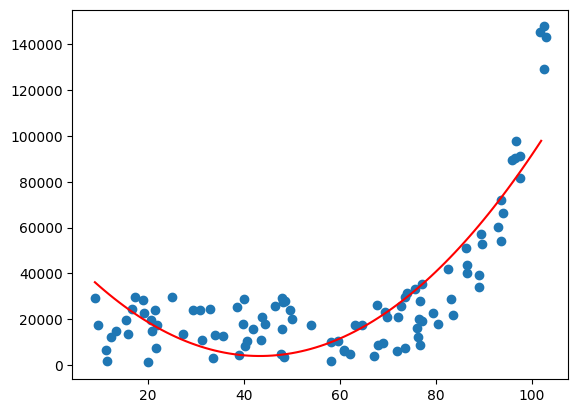

In [11]:
yy_2d = poly_2d.predict(xx_2d)
plt.scatter(X.x, y)
plt.plot(xx, yy_2d, c='r')

In [12]:
poly_2d.score(X_2, y)

0.7359753787024842

In [13]:
exersice.append('reg-poly2')
timer.append(end - start)
scores.append(poly_2d.score(X_2, y))

4. Загрузите набор данных для классификации "gen_classification".

In [14]:
data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML3.1%20polynomial%20features/gen_classification.csv",index_col=0)
data.head()

,x1,x2,y
0,0.048289,0.267592,1
1,1.363151,0.171123,0
2,-0.424253,0.893937,0
3,0.112344,0.565672,0
4,-1.262453,0.521735,0


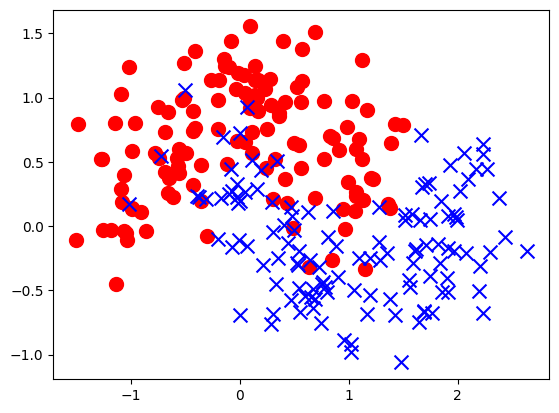

In [15]:
y = data.y
X = data.drop(["y"], axis=1)
plt.scatter(X.iloc[:, 0][y==0], X.iloc[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X.iloc[:, 0][y==1], X.iloc[:, 1][y==1], marker="x", c='b', s=100)

5. Постройте линейную классификацию, изобразите ее на графике и оцените точность.

In [16]:
from sklearn.linear_model import LogisticRegression
start = time.time()
logistic = LogisticRegression().fit(X, y)
end = time.time()
print("Time: ", end - start)

Time:  0.0023419857025146484


C:\Users\_System\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


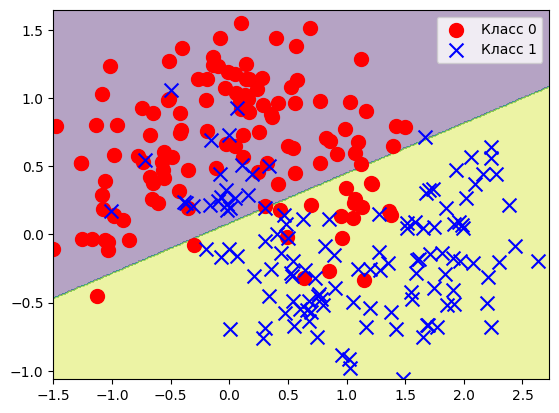

In [17]:
# 1. Конвертируем в numpy для безопасной работы с индексами
X_np = X.to_numpy()

# 2. Создаем сетку
xx, yy = np.meshgrid(
    np.arange(X_np[:, 0].min(), X_np[:, 0].max() + 0.1, 0.01),
    np.arange(X_np[:, 1].min(), X_np[:, 1].max() + 0.1, 0.01)
)

# 3. Подготовка данных для предсказания
XX = np.array(list(zip(xx.ravel(), yy.ravel())))

# 4. Предсказание
Z = logistic.predict(XX).reshape(xx.shape)

# 5. Визуализация
plt.contourf(xx, yy, Z, alpha=0.4)
# Используем numpy-индексацию для X_np и y
plt.scatter(X_np[y == 0, 0], X_np[y == 0, 1], marker="o", c='r', s=100, label='Класс 0')
plt.scatter(X_np[y == 1, 0], X_np[y == 1, 1], marker="x", c='b', s=100, label='Класс 1')

plt.legend()
plt.show()

In [18]:
logistic.score(X, y)

0.832

In [19]:
exersice.append('clas')
timer.append(end - start)
scores.append(logistic.score(X, y))

6. Введите в данные признаки третьего порядка и постройте классификацию. Сравните с предыдущей моделью.

In [20]:
start = time.time()
class_transform = PolynomialFeatures(degree=3, include_bias=False)
X_3 = class_transform.fit_transform(X)
end = time.time()
print("Time : ", end - start)

Time :  0.0012621879577636719


In [21]:
X_3.shape

(250, 9)

In [22]:
(250, 9)
start = time.time()
class_3 = LogisticRegression().fit(X_3, y)
end = time.time()
print("Time : ", end - start)

Time :  0.0028867721557617188


C:\Users\_System\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


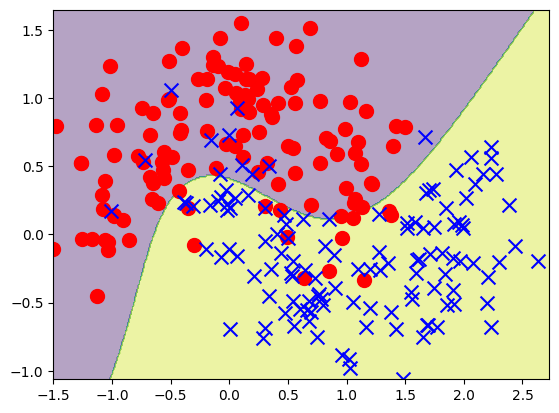

In [23]:
Z = class_3.predict(class_transform.transform(XX)).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X.iloc[:, 0][y==0], X.iloc[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X.iloc[:, 0][y==1], X.iloc[:, 1][y==1], marker="x", c='b', s=100)

In [24]:
class_3.score(X_3, y)

0.9

In [25]:
exersice.append('clas-poly3')
timer.append(end - start)
scores.append(class_3.score(X_3, y))

7. Загрузите набор данных, содержащий данные о продаже домов в округе King county, США.

In [26]:
data_kc_prices = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML3.1%20polynomial%20features/kc_house_data.csv")
data_kc_prices.shape

(21613, 21)

In [27]:
data_kc_prices.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [28]:
y_kc_prices = data_kc_prices.price
X_kc_prices = data_kc_prices.drop(["id", "date", "price"], axis=1)
X_kc_prices.shape, y_kc_prices.shape

((21613, 18), (21613,))

In [29]:
start = time.time()
reg_kc_multiple = LinearRegression().fit(X_kc_prices, y_kc_prices)
end = time.time()
print("Time: ", end - start)

Time:  0.0039637088775634766


In [30]:
reg_kc_multiple.score(X_kc_prices, y_kc_prices)

0.699747189010915

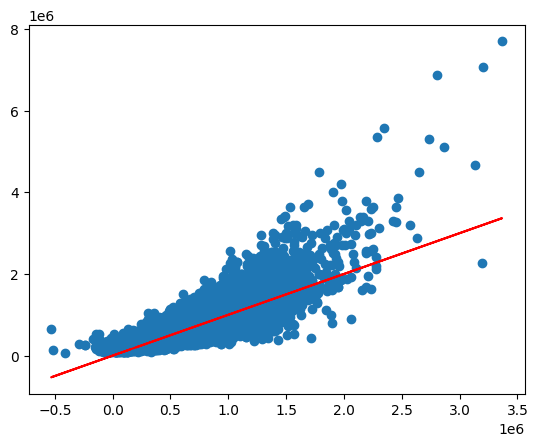

In [31]:
y_pred_kc_prices = reg_kc_multiple.predict(X_kc_prices)
plt.scatter(y_pred_kc_prices, y_kc_prices)
plt.plot(y_pred_kc_prices, y_pred_kc_prices, c='r')

In [32]:
reg_kc_multiple.score(X_kc_prices, y_kc_prices)

0.699747189010915

In [33]:
exersice.append('reg')
timer.append(end - start)
scores.append(reg_kc_multiple.score(X_kc_prices, y_kc_prices))

In [34]:
start = time.time()
X_3_kc_prices = (poly_features_kc_prices := PolynomialFeatures(degree=3)).fit_transform(X_kc_prices)
end = time.time()

print("Time: ", end - start)

Time:  0.07136130332946777


In [35]:
reg_poly2_kc = LinearRegression().fit(X_3_kc_prices, y_kc_prices)
reg_poly2_kc.score(X_3_kc_prices, y_kc_prices)

0.8326020796592948

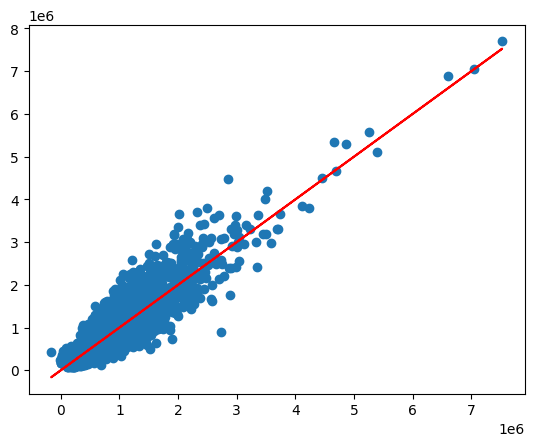

In [36]:
y_pred_kc_prices = reg_poly2_kc.predict(X_3_kc_prices)
plt.scatter(y_pred_kc_prices, y_kc_prices)
plt.plot(y_pred_kc_prices, y_pred_kc_prices, c='r')

In [37]:
reg_poly2_kc.coef_

array([-1.63359180e-08, -7.93153962e-08,  4.69899891e-08, ...,
       -2.63167351e-08, -4.34519478e-09, -6.03546545e-12], shape=(1330,))

In [38]:
reg_poly2_kc.score(X_3_kc_prices, y_kc_prices)

0.8326020796592948

In [39]:
exersice.append('reg-poly3')
timer.append(end - start)
scores.append(reg_poly2_kc.score(X_3_kc_prices, y_kc_prices))

# Задания для самостоятельного выполнения

1. В выполненной работе добавьте замер времени обучения каждой модели.

In [40]:
DF = {'Excercise': exersice, 'Time' : timer}
DF = pd.DataFrame(DF)
DF

,Excercise,Time
0,reg,0.001008
1,reg-poly2,0.000579
2,clas,0.002342
3,clas-poly3,0.002887
4,reg,0.003964
5,reg-poly3,0.071361


2. На датасете "gen_regression" постройте модель пятого, десятого и сотого порядков. Сравните эффективность и время обучения каждой модели.

In [41]:
data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML3.1%20polynomial%20features/data/gen_regression.csv", index_col=0)
X = data.x
y = data.y
X = pd.DataFrame(X)

In [42]:
degrees = [5, 10, 100]

results = {}

for degree in degrees:
    start_time = time.time()

    poly = PolynomialFeatures(degree=degree)
    X_test_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_test_poly, y)
    end_time = time.time()
    y_pred = model.predict(X_test_poly)
    score = model.score(X_test_poly, y)
    elapsed_time = end_time - start_time
    
    results[degree] = (score, elapsed_time)

results

{5: (0.9217478060447017, 0.001245737075805664),
 10: (0.9222468251462042, 0.0008406639099121094),
 100: (0.7924620004601313, 0.003234386444091797)}

4. Составьте таблицу эффективности разных моделей для каждой задачи. В таблице должна быть информация о времени обучения модели и получившейся точности. Сделайте вывод о целесообразности применения разных степеней полиномов.

In [43]:
Dd = {'Exercise': exersice, 'Time': timer, 'Score': scores}
m_df = pd.DataFrame(Dd)
m_df.head()

,Exercise,Time,Score
0,reg,0.001008,0.374674
1,reg-poly2,0.000579,0.735975
2,clas,0.002342,0.832000
3,clas-poly3,0.002887,0.900000
4,reg,0.003964,0.699747


5. Для линейной модели в задаче о продаже домов выведите коэффициенты модели и названия соответствующих атрибутов. Сделайте вывод об относительной важности атрибутов.

In [44]:
features = reg_kc_multiple.feature_names_in_
coefficients_king = pd.DataFrame({"Признак": features, "Коэффициент": reg_kc_multiple.coef_})
coefficients_king.sort_values(by="Коэффициент", ascending=False, inplace=True)
coefficients_king

,Признак,Коэффициент
14,lat,602748.226449
5,waterfront,582960.458423
8,grade,95890.445151
6,view,52870.942384
1,bathrooms,41144.278532
7,condition,26385.649139
4,floors,6689.550115
2,sqft_living,110.442865
9,sqft_above,70.785224
10,sqft_basement,39.657640


6. Попробуйте также проинтерпретировать полиномиальную модель.

In [45]:
features = poly_features_kc_prices.get_feature_names_out(X_kc_prices.columns)
coefficients_king = pd.DataFrame({"Признак": features, "Коэффициент": reg_poly2_kc.coef_})
coefficients_king.sort_values(by="Коэффициент", ascending=False, inplace=True)

coefficients_king

,Признак,Коэффициент
1261,yr_built zipcode long,0.042422
526,sqft_living^2 lat,0.028320
1182,sqft_above yr_built^2,0.024386
622,sqft_living yr_built^2,0.024255
610,sqft_living sqft_above lat,0.023470
...,...,...
1260,yr_built zipcode lat,-0.031115
645,sqft_living long sqft_living15,-0.035315
1171,sqft_above^2 long,-0.038658
611,sqft_living sqft_above long,-0.046691
